<div style='background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 16px; text-align: center;'>
  <h1 style='color: #e94560; font-size: 2.2em; margin-bottom: 10px;'>💶 Détection de Faux Billets en Euros</h1>
  <h3 style='color: #a8b2d8; font-weight: normal;'>Machine Learning — Classification supervisée & non supervisée</h3>
  <p style='color: #64ffda; margin-top: 15px; font-size: 0.95em;'>Auteur : Sona Koulibaly | Python 3.12 | Scikit-learn</p>
</div>

---
## Sommaire
1. [Importations & Configuration](#1)
2. [Chargement & Exploration des données](#2)
3. [Analyse Exploratoire (EDA)](#3)
4. [Préparation des données](#4)
5. [Modèle 1 — Régression Logistique](#5)
6. [Modèle 2 — K-Nearest Neighbors](#6)
7. [Modèle 3 — Random Forest](#7)
8. [Modèle 4 — K-Means (non supervisé)](#8)
9. [Comparaison des modèles](#9)
10. [Visualisation PCA](#10)
11. [Export des pipelines](#11)

<a id='1'></a>
## 1. Importations & Configuration

In [1]:
# =============================================================================
# BLOC 1 — IMPORTATIONS
# Toutes les librairies nécessaires au projet :
#   - pandas / numpy     : manipulation des données
#   - matplotlib/seaborn : visualisations statiques
#   - plotly             : visualisations interactives
#   - sklearn            : modèles ML + évaluation + pipelines
#   - joblib             : sauvegarde des modèles entraînés
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import joblib
import os

# --- Modèles ML ---
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

# --- Prétraitement & Pipeline ---
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
)

# --- Évaluation ---
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)

# --- Réduction de dimension pour visualisation ---
from sklearn.decomposition import PCA

# --- Configuration générale ---
warnings.filterwarnings('ignore')        # masquer les warnings non critiques
pd.set_option('display.max_columns', 20) # afficher toutes les colonnes
pd.set_option('display.float_format', '{:.4f}'.format)  # 4 décimales
plt.style.use('seaborn-v0_8-whitegrid') # style matplotlib propre
SEED = 42                                # graine aléatoire pour reproductibilité

print('✅ Toutes les librairies importées avec succès')
print(f'   Seed de reproductibilité : {SEED}')

✅ Toutes les librairies importées avec succès
   Seed de reproductibilité : 42


<a id='2'></a>
## 2. Chargement & Exploration des données

In [2]:
# =============================================================================
# BLOC 2 — CHARGEMENT DU DATASET
# Le fichier billets.csv contient 1500 billets décrits par 6 mesures géométriques.
# Séparateur : point-virgule (;)
# Colonne cible : is_genuine (True = vrai billet, False = faux billet)
# =============================================================================

# Chemin vers les données (relatif au notebook)
DATA_PATH = '../data/billets.csv'

# Chargement avec le bon séparateur
df = pd.read_csv(DATA_PATH, sep=';')

# Conversion de la colonne cible en booléen propre
# (au cas où elle serait lue comme string 'True'/'False')
df['is_genuine'] = df['is_genuine'].astype(bool)

print('=' * 55)
print(f'  DATASET CHARGÉ : {DATA_PATH}')
print('=' * 55)
print(f'  Lignes       : {df.shape[0]}')
print(f'  Colonnes     : {df.shape[1]}')
print(f'  Vrais billets: {df["is_genuine"].sum()}')
print(f'  Faux billets : {(~df["is_genuine"]).sum()}')
print('=' * 55)
df.head(10)

  DATASET CHARGÉ : ../data/billets.csv
  Lignes       : 1500
  Colonnes     : 7
  Vrais billets: 1000
  Faux billets : 500


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.8100,104.8600,104.9500,4.5200,2.8900,112.8300
1,True,171.4600,103.3600,103.6600,3.7700,2.9900,113.0900
2,True,172.6900,104.4800,103.5000,4.4000,2.9400,113.1600
3,True,171.3600,103.9100,103.9400,3.6200,3.0100,113.5100
4,True,171.7300,104.2800,103.4600,4.0400,3.4800,112.5400
5,True,172.1700,103.7400,104.0800,4.4200,2.9500,112.8100
6,True,172.3400,104.1800,103.8500,4.5800,3.2600,112.8100
7,True,171.8800,103.7600,104.0800,3.9800,2.9200,113.0800
8,True,172.4700,103.9200,103.6700,4.0000,3.2500,112.8500
9,True,172.4700,104.0700,104.0200,4.0400,3.2500,113.4500


In [3]:
# =============================================================================
# BLOC 3 — INFORMATIONS STRUCTURELLES
# Vérification des types de données et détection des valeurs manquantes.
# Un pipeline ML robuste exige des données propres avant tout entraînement.
# =============================================================================

print('--- Types de données ---')
print(df.dtypes)
print()
print('--- Valeurs manquantes par colonne ---')
missing = df.isnull().sum()
print(missing)
print()
total_missing = missing.sum()
print(f'Total valeurs manquantes : {total_missing}')

if total_missing > 0:
    print('⚠️  Des valeurs manquantes ont été détectées — traitement nécessaire')
else:
    print('✅ Aucune valeur manquante — données prêtes pour la modélisation')

--- Types de données ---
is_genuine         bool
diagonal        float64
height_left     float64
height_right    float64
margin_low      float64
margin_up       float64
length          float64
dtype: object

--- Valeurs manquantes par colonne ---
is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

Total valeurs manquantes : 37
⚠️  Des valeurs manquantes ont été détectées — traitement nécessaire


In [4]:
# =============================================================================
# BLOC 4 — STATISTIQUES DESCRIPTIVES
# Les statistiques de base (moyenne, écart-type, min/max, quartiles) permettent
# de comprendre la distribution de chaque dimension géométrique.
# On les calcule séparément pour les vrais et les faux billets afin de
# détecter les premières différences exploitables par un algorithme.
# =============================================================================

# Variables prédictives (les 6 mesures géométriques)
FEATURES = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']

print('=== Statistiques globales ===')
display(df[FEATURES].describe().round(3))

print('\n=== Statistiques — Vrais billets ===')
display(df[df['is_genuine']][FEATURES].describe().round(3))

print('\n=== Statistiques — Faux billets ===')
display(df[~df['is_genuine']][FEATURES].describe().round(3))

=== Statistiques globales ===


,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.0000,1500.0000,1500.0000,1463.0000,1500.0000,1500.0000
mean,171.9580,104.0300,103.9200,4.4860,3.1510,112.6780
std,0.3050,0.2990,0.3260,0.6640,0.2320,0.8730
min,171.0400,103.1400,102.8200,2.9800,2.2700,109.4900
25%,171.7500,103.8200,103.7100,4.0150,2.9900,112.0300
50%,171.9600,104.0400,103.9200,4.3100,3.1400,112.9600
75%,172.1700,104.2300,104.1500,4.8700,3.3100,113.3400
max,173.0100,104.8800,104.9500,6.9000,3.9100,114.4400



=== Statistiques — Vrais billets ===


,diagonal,height_left,height_right,margin_low,margin_up,length
count,1000.0000,1000.0000,1000.0000,971.0000,1000.0000,1000.0000
mean,171.9870,103.9490,103.8090,4.1160,3.0520,113.2020
std,0.3000,0.3000,0.2920,0.3190,0.1860,0.3600
min,171.0400,103.1400,102.8200,2.9800,2.2700,111.7600
25%,171.7900,103.7400,103.6100,3.9050,2.9300,112.9500
50%,171.9900,103.9500,103.8100,4.1100,3.0500,113.2050
75%,172.2000,104.1400,104.0000,4.3400,3.1800,113.4600
max,172.9200,104.8600,104.9500,5.0400,3.7400,114.4400



=== Statistiques — Faux billets ===


,diagonal,height_left,height_right,margin_low,margin_up,length
count,500.0000,500.0000,500.0000,492.0000,500.0000,500.0000
mean,171.9010,104.1900,104.1440,5.2160,3.3500,111.6310
std,0.3070,0.2240,0.2710,0.5540,0.1800,0.6160
min,171.0400,103.5100,103.4300,3.8200,2.9200,109.4900
25%,171.6900,104.0400,103.9500,4.8400,3.2200,111.2000
50%,171.9100,104.1800,104.1600,5.1900,3.3500,111.6300
75%,172.0920,104.3320,104.3200,5.5920,3.4720,112.0300
max,173.0100,104.8800,104.9500,6.9000,3.9100,113.8500


<a id='3'></a>
## 3. Analyse Exploratoire (EDA)

In [5]:
# =============================================================================
# BLOC 5 — RÉPARTITION VRAIS / FAUX BILLETS
# Visualisation de l'équilibre des classes.
# Un déséquilibre important (ex : 95%/5%) nécessiterait des techniques
# spéciales (SMOTE, class_weight). On vérifie ici si c'est le cas.
# =============================================================================

# Comptage des classes
counts = df['is_genuine'].value_counts()
labels = ['Vrai billet', 'Faux billet']
colors = ['#2ecc71', '#e74c3c']

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Répartition des classes', 'Proportion (%)'),
    specs=[[{'type': 'bar'}, {'type': 'pie'}]]
)

# Graphique en barres
fig.add_trace(
    go.Bar(
        x=labels,
        y=[counts[True], counts[False]],
        marker_color=colors,
        text=[counts[True], counts[False]],
        textposition='outside',
        name='Effectif'
    ), row=1, col=1
)

# Camembert
fig.add_trace(
    go.Pie(
        labels=labels,
        values=[counts[True], counts[False]],
        marker_colors=colors,
        hole=0.4,
        textinfo='label+percent'
    ), row=1, col=2
)

fig.update_layout(
    title_text='Distribution des classes — Vrais vs Faux billets',
    title_font_size=16,
    showlegend=False,
    height=400
)
fig.show()

# Calcul du ratio de déséquilibre
ratio = counts[True] / counts[False]
print(f'Ratio vrais/faux : {ratio:.2f}')
print(f'→ Déséquilibre modéré (2:1) — class_weight="balanced" recommandé')

Ratio vrais/faux : 2.00
→ Déséquilibre modéré (2:1) — class_weight="balanced" recommandé


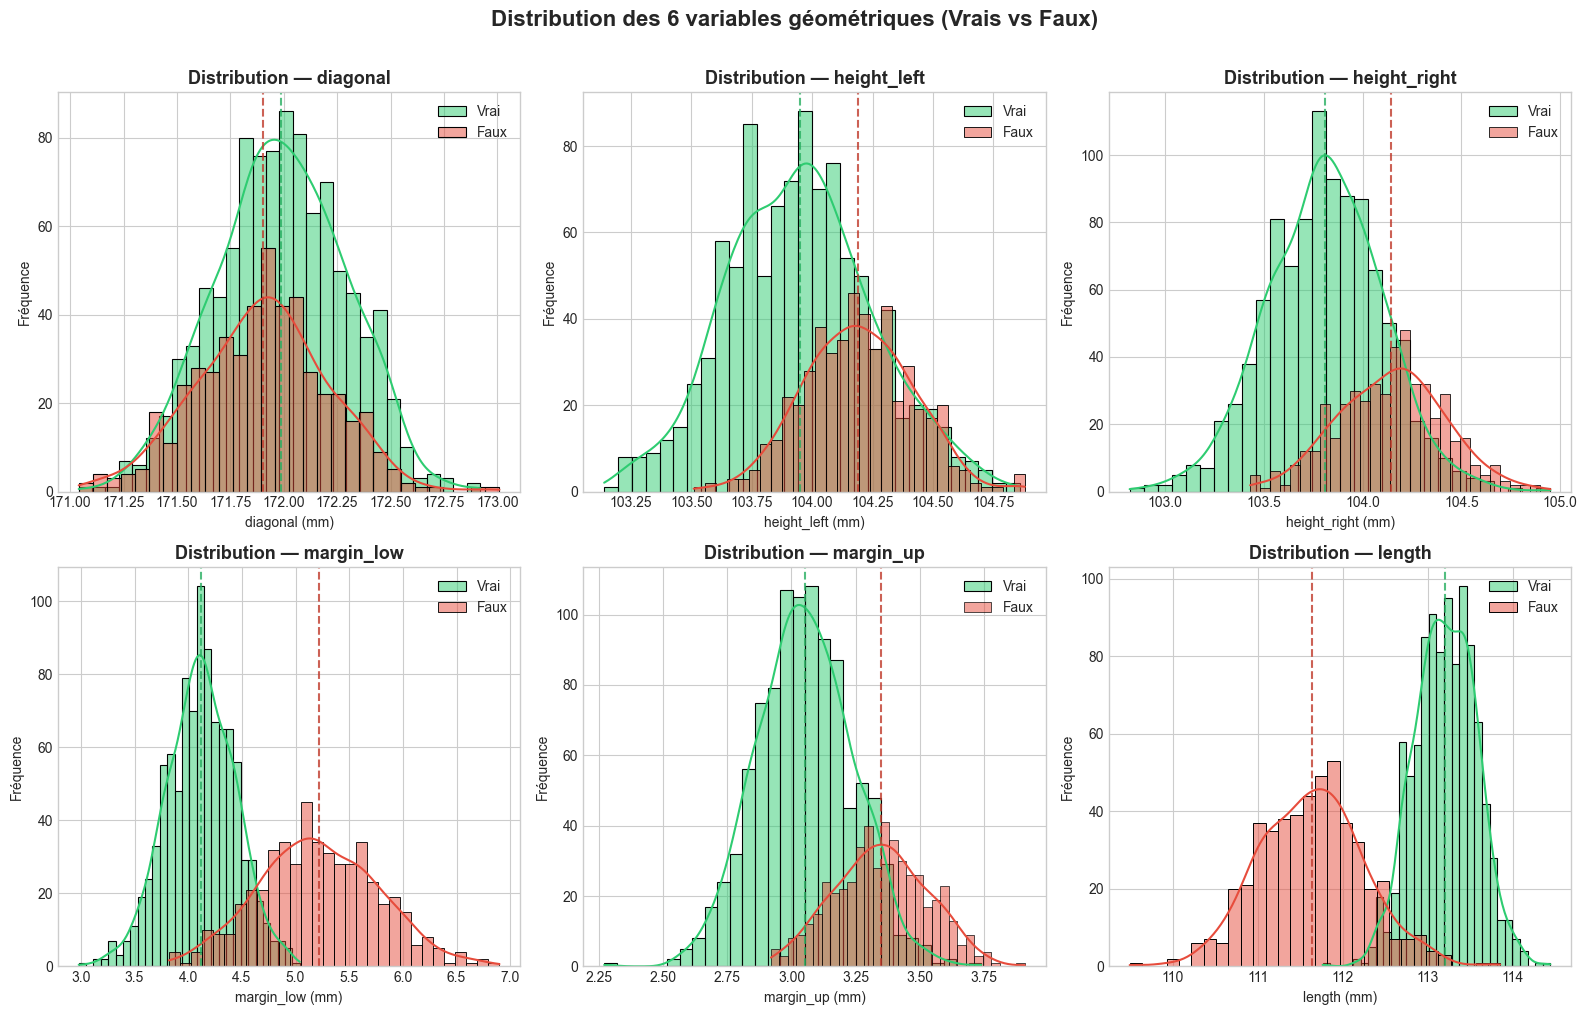

In [6]:
# =============================================================================
# BLOC 6 — DISTRIBUTIONS DES VARIABLES PAR CLASSE
# On trace les histogrammes + courbes de densité (KDE) pour chaque feature,
# en superposant vrais et faux billets.
# Une bonne séparation visuelle entre les deux distributions = feature utile.
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(FEATURES):
    ax = axes[i]
    
    # Distribution des vrais billets (vert)
    sns.histplot(
        data=df[df['is_genuine']], x=feature,
        ax=ax, color='#2ecc71', alpha=0.5, kde=True,
        label='Vrai', bins=30
    )
    # Distribution des faux billets (rouge)
    sns.histplot(
        data=df[~df['is_genuine']], x=feature,
        ax=ax, color='#e74c3c', alpha=0.5, kde=True,
        label='Faux', bins=30
    )
    
    ax.set_title(f'Distribution — {feature}', fontsize=13, fontweight='bold')
    ax.set_xlabel(f'{feature} (mm)')
    ax.set_ylabel('Fréquence')
    ax.legend()
    
    # Ligne verticale = moyenne de chaque classe
    mean_true = df[df['is_genuine']][feature].mean()
    mean_false = df[~df['is_genuine']][feature].mean()
    ax.axvline(mean_true, color='#27ae60', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.axvline(mean_false, color='#c0392b', linestyle='--', linewidth=1.5, alpha=0.8)

plt.suptitle(
    'Distribution des 6 variables géométriques (Vrais vs Faux)',
    fontsize=16, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

In [7]:
# =============================================================================
# BLOC 7 — BOXPLOTS INTERACTIFS
# Les boxplots permettent de voir les médianes, quartiles et outliers.
# Avec Plotly, on peut interagir (zoom, hover) pour une analyse fine.
# =============================================================================

# Préparation : colonne texte pour l'affichage
df_plot = df.copy()
df_plot['Type'] = df_plot['is_genuine'].map({True: 'Vrai billet', False: 'Faux billet'})

fig = make_subplots(rows=2, cols=3, subplot_titles=FEATURES)

color_map = {'Vrai billet': '#2ecc71', 'Faux billet': '#e74c3c'}
row_col = [(1,1),(1,2),(1,3),(2,1),(2,2),(2,3)]

for i, feature in enumerate(FEATURES):
    r, c = row_col[i]
    for label, color in color_map.items():
        data_sub = df_plot[df_plot['Type'] == label][feature]
        fig.add_trace(
            go.Box(
                y=data_sub,
                name=label,
                marker_color=color,
                showlegend=(i == 0),  # légende une seule fois
                boxmean=True          # afficher la moyenne en plus de la médiane
            ), row=r, col=c
        )

fig.update_layout(
    title_text='Boxplots comparatifs — Vrais vs Faux billets',
    title_font_size=16,
    height=700,
    showlegend=True
)
fig.show()

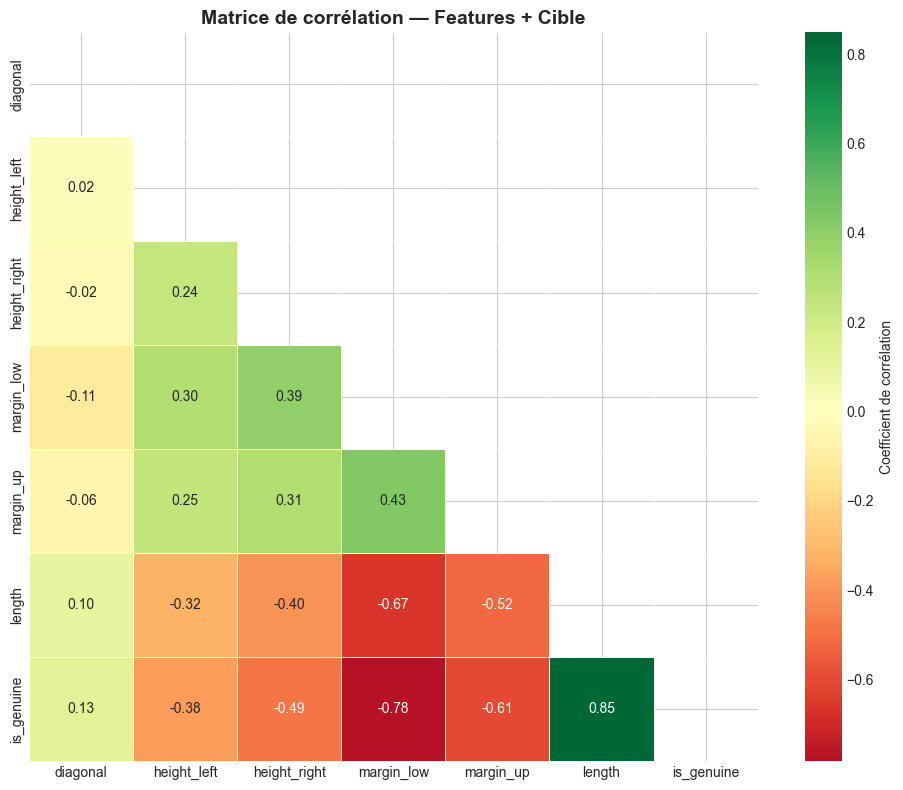


Corrélation de chaque feature avec is_genuine :
length          0.8490
diagonal        0.1330
height_left    -0.3800
height_right   -0.4850
margin_up      -0.6060
margin_low     -0.7830


In [8]:
# =============================================================================
# BLOC 8 — MATRICE DE CORRÉLATION
# Identifier les corrélations entre variables :
#   - Une forte corrélation entre features peut indiquer de la redondance.
#   - La corrélation avec la cible révèle les variables les plus discriminantes.
# =============================================================================

# Encode la cible en numérique pour le calcul de corrélation
df_corr = df[FEATURES + ['is_genuine']].copy()
df_corr['is_genuine'] = df_corr['is_genuine'].astype(int)

corr_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # masque triangle supérieur

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Coefficient de corrélation'}
)
plt.title(
    'Matrice de corrélation — Features + Cible',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

# Corrélation de chaque feature avec la cible (tri décroissant)
print('\nCorrélation de chaque feature avec is_genuine :')
target_corr = corr_matrix['is_genuine'].drop('is_genuine').sort_values(ascending=False)
print(target_corr.round(3).to_string())

<a id='4'></a>
## 4. Préparation des données

In [9]:
# =============================================================================
# BLOC 9 — TRAITEMENT DES NaN + SPLIT TRAIN / TEST
# Le dataset contient des valeurs manquantes → on les remplace par la médiane
# de chaque colonne (plus robuste que la moyenne face aux outliers).
# SimpleImputer est intégré dans le pipeline pour éviter tout data leakage.
# =============================================================================

from sklearn.impute import SimpleImputer

# Vérification des NaN avant traitement
print("Valeurs manquantes par colonne :")
print(df[FEATURES].isnull().sum())
print(f"Total NaN : {df[FEATURES].isnull().sum().sum()}")

# Séparation features / cible
X = df[FEATURES].copy()
y = df['is_genuine'].astype(int)

# Imputation des NaN par la médiane
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=FEATURES)

# Split stratifié 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f'\nAprès imputation — NaN restants : {pd.DataFrame(X_imputed).isnull().sum().sum()}')
print(f'Entraînement : {len(X_train)} | Test : {len(X_test)}')

Valeurs manquantes par colonne :
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64
Total NaN : 37

Après imputation — NaN restants : 0
Entraînement : 1200 | Test : 300


<a id='5'></a>
## 5. Modèle 1 — Régression Logistique

In [10]:
# =============================================================================
# BLOC 10 — RÉGRESSION LOGISTIQUE
#
# La régression logistique est le modèle de référence (baseline) en
# classification binaire. Elle est interprétable et rapide.
#
# PIPELINE = StandardScaler + LogisticRegression
#   → Le scaler est INTÉGRÉ dans le pipeline. Cela évite le data leakage :
#     la normalisation est apprise uniquement sur X_train, puis appliquée
#     à X_test. En production, un seul objet à sauvegarder = pipeline complet.
#
# class_weight='balanced' → compense le déséquilibre 2:1 (1000 vrais / 500 faux)
# max_iter=1000 → évite les erreurs de convergence
# =============================================================================

# Construction du pipeline
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),          # normalisation Z-score
    ('model', LogisticRegression(
        class_weight='balanced',           # gestion du déséquilibre
        max_iter=1000,                     # convergence garantie
        random_state=SEED
    ))
])

# Entraînement
pipeline_lr.fit(X_train, y_train)

# Prédictions
y_pred_lr = pipeline_lr.predict(X_test)
y_proba_lr = pipeline_lr.predict_proba(X_test)[:, 1]  # probabilité d'être vrai

# Métriques
acc_lr  = accuracy_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_proba_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)

print('=== Régression Logistique — Résultats ===')
print(f'  Accuracy  : {acc_lr:.4f}')
print(f'  F1-Score  : {f1_lr:.4f}')
print(f'  AUC-ROC   : {auc_lr:.4f}')
print(f'  Précision : {prec_lr:.4f}')
print(f'  Rappel    : {rec_lr:.4f}')
print()
print('Rapport de classification complet :')
print(classification_report(y_test, y_pred_lr, target_names=['Faux', 'Vrai']))

=== Régression Logistique — Résultats ===
  Accuracy  : 0.9867
  F1-Score  : 0.9899
  AUC-ROC   : 0.9995
  Précision : 0.9949
  Rappel    : 0.9850

Rapport de classification complet :
              precision    recall  f1-score   support

        Faux       0.97      0.99      0.98       100
        Vrai       0.99      0.98      0.99       200

    accuracy                           0.99       300
   macro avg       0.98      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [11]:
# =============================================================================
# BLOC 11 — CROSS-VALIDATION LOGISTIC REGRESSION
# On utilise X_imputed (sans NaN) et on intègre l'imputer dans le pipeline
# pour que chaque fold soit traité proprement sans data leakage.
# =============================================================================

# Ajout de l'imputer directement dans le pipeline LR
pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # gestion des NaN
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=SEED
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Cross-validation sur X original (avec NaN) — l'imputer dans le pipeline gère ça
cv_scores_lr = cross_val_score(
    pipeline_lr, X, y,
    cv=cv,
    scoring='f1'
)

print('=== Cross-Validation (5-Fold) — Logistic Regression ===')
print(f'  F1 par fold   : {[f"{s:.4f}" for s in cv_scores_lr]}')
print(f'  F1 moyen      : {cv_scores_lr.mean():.4f}')
print(f'  Écart-type    : {cv_scores_lr.std():.4f}')

=== Cross-Validation (5-Fold) — Logistic Regression ===
  F1 par fold   : ['0.9950', '0.9925', '0.9849', '0.9975', '0.9925']
  F1 moyen      : 0.9925
  Écart-type    : 0.0042


<a id='6'></a>
## 6. Modèle 2 — K-Nearest Neighbors (KNN)

In [12]:
# =============================================================================
# BLOC 12 — K-NEAREST NEIGHBORS + GRIDSEACHCV
#
# KNN classe un point en regardant les k voisins les plus proches.
# Le choix de k est crucial : trop petit = surajustement, trop grand = biais.
#
# GridSearchCV teste automatiquement plusieurs valeurs de k et retient la
# meilleure selon la cross-validation. C'est le tuning des hyperparamètres.
# =============================================================================

# Pipeline de base pour KNN (nécessite normalisation — distances sensibles à l'échelle)
pipeline_knn_base = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # gestion des NaN
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

# Grille d'hyperparamètres à tester
# Note : 'model__' = préfixe pour accéder aux paramètres de l'étape 'model'
param_grid_knn = {
    'model__n_neighbors': [3, 5, 7, 9, 11, 15],  # valeurs de k à tester
    'model__weights': ['uniform', 'distance'],     # vote égal vs pondéré par distance
    'model__metric': ['euclidean', 'manhattan']    # métrique de distance
}

# Recherche par grille avec cross-validation 5-fold
grid_knn = GridSearchCV(
    pipeline_knn_base,
    param_grid_knn,
    cv=cv,
    scoring='f1',
    n_jobs=-1,   # utilise tous les cœurs du processeur
    verbose=0
)
grid_knn.fit(X_train, y_train)

# Récupération du meilleur pipeline
pipeline_knn = grid_knn.best_estimator_

# Prédictions avec le meilleur modèle
y_pred_knn = pipeline_knn.predict(X_test)
y_proba_knn = pipeline_knn.predict_proba(X_test)[:, 1]

# Métriques
acc_knn  = accuracy_score(y_test, y_pred_knn)
f1_knn   = f1_score(y_test, y_pred_knn)
auc_knn  = roc_auc_score(y_test, y_proba_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn  = recall_score(y_test, y_pred_knn)

print('=== KNN — Meilleurs hyperparamètres ===')
print(f'  {grid_knn.best_params_}')
print()
print('=== KNN — Résultats ===')
print(f'  Accuracy  : {acc_knn:.4f}')
print(f'  F1-Score  : {f1_knn:.4f}')
print(f'  AUC-ROC   : {auc_knn:.4f}')
print(f'  Précision : {prec_knn:.4f}')
print(f'  Rappel    : {rec_knn:.4f}')
print()
print(classification_report(y_test, y_pred_knn, target_names=['Faux', 'Vrai']))

=== KNN — Meilleurs hyperparamètres ===
  {'model__metric': 'euclidean', 'model__n_neighbors': 15, 'model__weights': 'uniform'}

=== KNN — Résultats ===
  Accuracy  : 0.9867
  F1-Score  : 0.9900
  AUC-ROC   : 0.9994
  Précision : 0.9851
  Rappel    : 0.9950

              precision    recall  f1-score   support

        Faux       0.99      0.97      0.98       100
        Vrai       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.98      0.98       300
weighted avg       0.99      0.99      0.99       300



<a id='7'></a>
## 7. Modèle 3 — Random Forest

In [13]:
# =============================================================================
# BLOC 13 — RANDOM FOREST + GRIDSEACHCV
#
# Random Forest = ensemble de N arbres de décision entraînés sur des
# sous-échantillons différents (bagging). La prédiction finale = vote majoritaire.
#
# Avantages : résistant au surajustement, gère bien les données non normalisées,
# fournit l'importance des features.
#
# Ici pas de StandardScaler nécessaire (RF non sensible à l'échelle),
# mais on l'inclut quand même pour uniformiser les pipelines.
# =============================================================================

pipeline_rf_base = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # gestion des NaN
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=SEED
    ))
])

# Grille réduite pour éviter un temps de calcul trop long
param_grid_rf = {
    'model__n_estimators': [100, 200],       # nombre d'arbres
    'model__max_depth': [None, 10, 20],      # profondeur max (None = illimitée)
    'model__min_samples_split': [2, 5],      # min d'exemples pour diviser un nœud
    'model__max_features': ['sqrt', 'log2']  # nb features testées à chaque division
}

grid_rf = GridSearchCV(
    pipeline_rf_base,
    param_grid_rf,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid_rf.fit(X_train, y_train)

pipeline_rf = grid_rf.best_estimator_

y_pred_rf = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_proba_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)

print('=== Random Forest — Meilleurs hyperparamètres ===')
print(f'  {grid_rf.best_params_}')
print()
print('=== Random Forest — Résultats ===')
print(f'  Accuracy  : {acc_rf:.4f}')
print(f'  F1-Score  : {f1_rf:.4f}')
print(f'  AUC-ROC   : {auc_rf:.4f}')
print(f'  Précision : {prec_rf:.4f}')
print(f'  Rappel    : {rec_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['Faux', 'Vrai']))

=== Random Forest — Meilleurs hyperparamètres ===
  {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_split': 5, 'model__n_estimators': 100}

=== Random Forest — Résultats ===
  Accuracy  : 0.9900
  F1-Score  : 0.9925
  AUC-ROC   : 0.9991
  Précision : 0.9900
  Rappel    : 0.9950

              precision    recall  f1-score   support

        Faux       0.99      0.98      0.98       100
        Vrai       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [14]:
# =============================================================================
# BLOC 14 — IMPORTANCE DES FEATURES (Random Forest)
# Random Forest calcule l'importance de chaque variable dans les décisions.
# Cela nous aide à comprendre quelles mesures géométriques différencient
# le mieux les vrais des faux billets.
# =============================================================================

# Extraction de l'importance depuis le modèle RF dans le pipeline
importances = pipeline_rf.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=True)

fig = px.bar(
    feat_imp,
    orientation='h',
    title='Importance des features — Random Forest',
    labels={'value': 'Importance', 'index': 'Feature'},
    color=feat_imp.values,
    color_continuous_scale='Viridis'
)
fig.update_layout(height=400, showlegend=False)
fig.show()

print('Feature la plus discriminante :', feat_imp.idxmax())

Feature la plus discriminante : length


<a id='8'></a>
## 8. Modèle 4 — K-Means (non supervisé)

In [15]:
# =============================================================================
# BLOC 15 — K-MEANS (CLUSTERING NON SUPERVISÉ)
#
# KMeans ne connaît pas les étiquettes pendant l'entraînement.
# Il regroupe les billets en 2 clusters selon leur similarité géométrique.
#
# Après l'entraînement, on associe chaque cluster à une classe (vrai/faux)
# en regardant quel cluster contient le plus de vrais billets.
#
# C'est une approche non supervisée donc ses performances seront
# généralement inférieures aux modèles supervisés.
# =============================================================================

# On normalise manuellement ici (KMeans sensible à l'échelle)
scaler_km = StandardScaler()
X_train_scaled = scaler_km.fit_transform(X_train)
X_test_scaled  = scaler_km.transform(X_test)

# Entraînement KMeans sur les données d'entraînement
kmeans = KMeans(
    n_clusters=2,
    random_state=SEED,
    n_init=10     # 10 initialisations aléatoires → garde la meilleure
)
kmeans.fit(X_train_scaled)

# Association cluster → classe réelle
# Pour chaque cluster, on regarde si la majorité est vrai (1) ou faux (0)
train_labels = kmeans.labels_
cluster_0_genuine = y_train[train_labels == 0].mean()  # % vrais dans cluster 0
cluster_1_genuine = y_train[train_labels == 1].mean()  # % vrais dans cluster 1

# Le cluster avec le + grand % de vrais = cluster "vrai billet"
genuine_cluster = 0 if cluster_0_genuine > cluster_1_genuine else 1
print(f'Cluster associé aux vrais billets : {genuine_cluster}')
print(f'  % vrais dans cluster 0 : {cluster_0_genuine:.2%}')
print(f'  % vrais dans cluster 1 : {cluster_1_genuine:.2%}')

# Prédiction sur le jeu de test
raw_pred_km = kmeans.predict(X_test_scaled)
# On remappe : genuine_cluster → 1 (vrai), l'autre → 0 (faux)
y_pred_km = np.where(raw_pred_km == genuine_cluster, 1, 0)

# Métriques (pas de proba pour KMeans → AUC non calculable)
acc_km  = accuracy_score(y_test, y_pred_km)
f1_km   = f1_score(y_test, y_pred_km)
prec_km = precision_score(y_test, y_pred_km)
rec_km  = recall_score(y_test, y_pred_km)

print()
print('=== K-Means — Résultats ===')
print(f'  Accuracy  : {acc_km:.4f}')
print(f'  F1-Score  : {f1_km:.4f}')
print(f'  Précision : {prec_km:.4f}')
print(f'  Rappel    : {rec_km:.4f}')
print()
print(classification_report(y_test, y_pred_km, target_names=['Faux', 'Vrai']))

Cluster associé aux vrais billets : 1
  % vrais dans cluster 0 : 1.52%
  % vrais dans cluster 1 : 98.51%

=== K-Means — Résultats ===
  Accuracy  : 0.9867
  F1-Score  : 0.9900
  Précision : 0.9900
  Rappel    : 0.9900

              precision    recall  f1-score   support

        Faux       0.98      0.98      0.98       100
        Vrai       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.99      0.99      0.99       300



<a id='9'></a>
## 9. Comparaison des modèles

In [16]:
# =============================================================================
# BLOC 16 — TABLEAU COMPARATIF DES PERFORMANCES
# Synthèse de toutes les métriques pour les 4 modèles.
# Permet de choisir le meilleur modèle à déployer en production.
# =============================================================================

results = pd.DataFrame({
    'Modèle': ['Logistic Regression', 'KNN', 'Random Forest', 'K-Means'],
    'Accuracy': [acc_lr, acc_knn, acc_rf, acc_km],
    'F1-Score': [f1_lr, f1_knn, f1_rf, f1_km],
    'Précision': [prec_lr, prec_knn, prec_rf, prec_km],
    'Rappel': [rec_lr, rec_knn, rec_rf, rec_km],
    'AUC-ROC': [auc_lr, auc_knn, auc_rf, None],   # KMeans n'a pas de proba
    'Supervisé': ['Oui', 'Oui', 'Oui', 'Non']
})

# Mise en forme : arrondi à 4 décimales
numeric_cols = ['Accuracy', 'F1-Score', 'Précision', 'Rappel', 'AUC-ROC']
results[numeric_cols] = results[numeric_cols].round(4)

print('=== Comparaison des 4 modèles ===')
display(results.set_index('Modèle'))

# Meilleur modèle selon F1
best_idx = results['F1-Score'].idxmax()
best_model = results.loc[best_idx, 'Modèle']
best_f1 = results.loc[best_idx, 'F1-Score']
print(f'\n🏆 Meilleur modèle (F1) : {best_model} — F1 = {best_f1:.4f}')

=== Comparaison des 4 modèles ===


,Accuracy,F1-Score,Précision,Rappel,AUC-ROC,Supervisé
Modèle,,,,,,
Logistic Regression,0.9867,0.9899,0.9949,0.9850,0.9994,Oui
KNN,0.9867,0.9900,0.9851,0.9950,0.9994,Oui
Random Forest,0.9900,0.9925,0.9900,0.9950,0.9992,Oui
K-Means,0.9867,0.9900,0.9900,0.9900,NaN,Non



🏆 Meilleur modèle (F1) : Random Forest — F1 = 0.9925


In [17]:
# =============================================================================
# BLOC 17 — GRAPHIQUE COMPARATIF INTERACTIF
# Visualisation radar + barres pour comparer les métriques facilement.
# =============================================================================

fig = go.Figure()

colors_models = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
model_names = results['Modèle'].tolist()
metrics = ['Accuracy', 'F1-Score', 'Précision', 'Rappel']

for i, (_, row) in enumerate(results.iterrows()):
    fig.add_trace(go.Bar(
        name=row['Modèle'],
        x=metrics,
        y=[row[m] for m in metrics],
        marker_color=colors_models[i],
        text=[f"{row[m]:.3f}" for m in metrics],
        textposition='outside'
    ))

fig.update_layout(
    title='Comparaison des performances — 4 modèles',
    barmode='group',
    yaxis=dict(range=[0, 1.1], title='Score'),
    xaxis_title='Métrique',
    height=500,
    legend_title='Modèle'
)
fig.show()

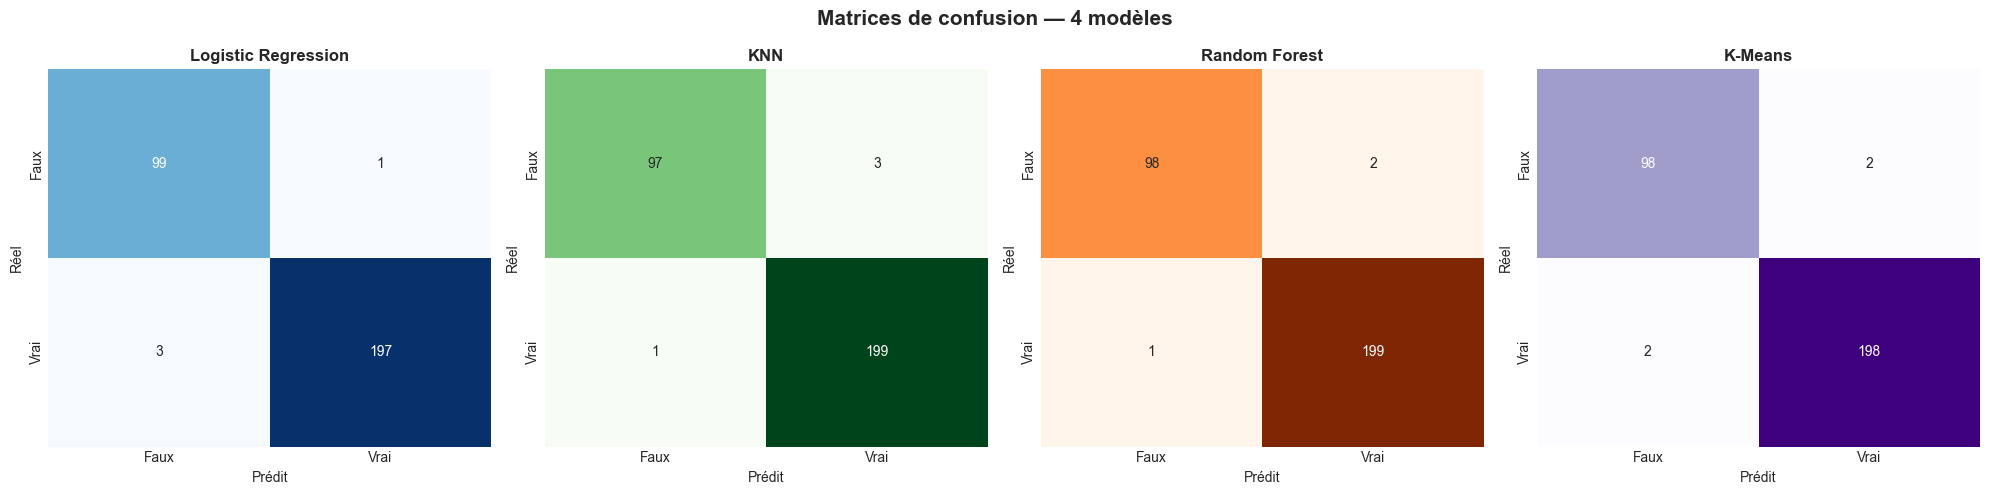

In [18]:
# =============================================================================
# BLOC 18 — MATRICES DE CONFUSION
# La matrice de confusion détaille :
#   - Vrais Positifs (VP)  : vrais billets correctement identifiés
#   - Vrais Négatifs (VN)  : faux billets correctement identifiés
#   - Faux Positifs (FP)   : faux billets classés comme vrais (dangereux !)
#   - Faux Négatifs (FN)   : vrais billets classés comme faux
# Dans le contexte anti-contrefaçon, les FP (faux billet accepté) sont
# les erreurs les plus critiques à minimiser.
# =============================================================================

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

model_results = [
    ('Logistic Regression', y_pred_lr, 'Blues'),
    ('KNN',                 y_pred_knn, 'Greens'),
    ('Random Forest',       y_pred_rf, 'Oranges'),
    ('K-Means',             y_pred_km, 'Purples'),
]

for ax, (name, y_pred, cmap) in zip(axes, model_results):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        ax=ax, cbar=False,
        xticklabels=['Faux', 'Vrai'],
        yticklabels=['Faux', 'Vrai']
    )
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle(
    'Matrices de confusion — 4 modèles',
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.show()

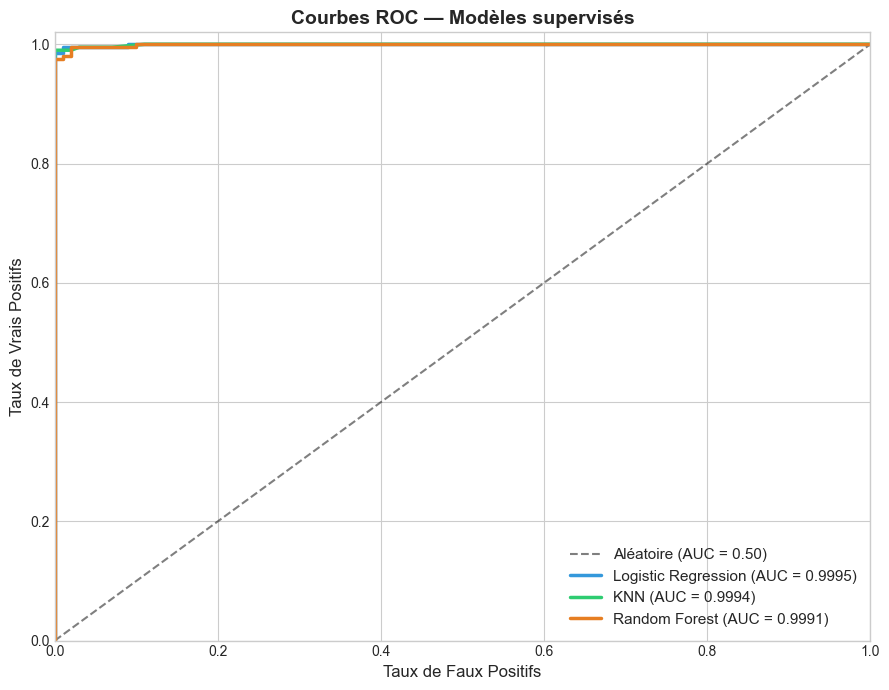

In [19]:
# =============================================================================
# BLOC 19 — COURBES ROC
# La courbe ROC (Receiver Operating Characteristic) trace le taux de vrais
# positifs vs faux positifs pour tous les seuils de décision.
# L'AUC (Area Under Curve) mesure la qualité globale : 1.0 = parfait, 0.5 = aléatoire.
# Seuls les modèles supervisés (qui donnent des probabilités) sont tracés.
# =============================================================================

fig, ax = plt.subplots(figsize=(9, 7))

# Ligne aléatoire de référence (AUC = 0.5)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aléatoire (AUC = 0.50)')

roc_models = [
    ('Logistic Regression', y_proba_lr, '#3498db'),
    ('KNN',                 y_proba_knn, '#2ecc71'),
    ('Random Forest',       y_proba_rf, '#e67e22'),
]

for name, y_proba, color in roc_models:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC = {auc:.4f})')

ax.set_xlabel('Taux de Faux Positifs', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs', fontsize=12)
ax.set_title('Courbes ROC — Modèles supervisés', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

<a id='10'></a>
## 10. Visualisation PCA

In [20]:
# =============================================================================
# BLOC 20 — ANALYSE EN COMPOSANTES PRINCIPALES (PCA)
#
# PCA réduit les 6 dimensions originales en 2 composantes principales.
# Ces 2 composantes capturent le maximum de variance du dataset.
# On peut ensuite visualiser les clusters en 2D pour comprendre si les
# classes sont naturellement séparables dans l'espace des features.
# =============================================================================

# Imputation des NaN avant PCA
X_clean = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(X),
    columns=FEATURES
)

# Normalisation de tout le dataset avant PCA
scaler_pca = StandardScaler()
X_scaled_all = scaler_pca.fit_transform(X_clean)

# Réduction à 2 composantes
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled_all)

# Variance expliquée par chaque composante
var_explained = pca.explained_variance_ratio_
print(f'Variance expliquée par PC1 : {var_explained[0]:.2%}')
print(f'Variance expliquée par PC2 : {var_explained[1]:.2%}')
print(f'Total expliqué             : {sum(var_explained):.2%}')

# DataFrame pour la visualisation
df_pca = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Type': y.map({1: 'Vrai billet', 0: 'Faux billet'})
})

# Visualisation interactive avec Plotly
fig = px.scatter(
    df_pca, x='PC1', y='PC2',
    color='Type',
    color_discrete_map={'Vrai billet': '#2ecc71', 'Faux billet': '#e74c3c'},
    title=f'PCA 2D — Séparation des classes '
          f'(variance expliquée : {sum(var_explained):.1%})',
    opacity=0.7,
    labels={
        'PC1': f'PC1 ({var_explained[0]:.1%})',
        'PC2': f'PC2 ({var_explained[1]:.1%})'
    }
)
fig.update_traces(marker=dict(size=5))
fig.update_layout(height=550)
fig.show()

Variance expliquée par PC1 : 43.02%
Variance expliquée par PC2 : 16.96%
Total expliqué             : 59.99%


<a id='11'></a>
## 11. Export des pipelines

In [25]:
# =============================================================================
# BLOC 21 — RÉENTRAÎNEMENT FINAL + SAUVEGARDE
# On réentraîne chaque pipeline sur X complet (avec imputer intégré)
# puis on sauvegarde les .pkl propres.
# =============================================================================

MODELS_DIR = '../backend/models'
os.makedirs(MODELS_DIR, exist_ok=True)

# --- Réentraînement sur tout le dataset (X avec NaN — l'imputer gère) ---
pipeline_lr.fit(X, y)
pipeline_knn.fit(X, y)
pipeline_rf.fit(X, y)

# --- Sauvegarde des pipelines supervisés ---
joblib.dump(pipeline_lr,  os.path.join(MODELS_DIR, 'pipeline_lr.pkl'))
joblib.dump(pipeline_knn, os.path.join(MODELS_DIR, 'pipeline_knn.pkl'))
joblib.dump(pipeline_rf,  os.path.join(MODELS_DIR, 'pipeline_rf.pkl'))

# --- KMeans bundle ---
kmeans_bundle = {
    'model': kmeans,
    'scaler': scaler_km,
    'genuine_cluster': genuine_cluster
}
joblib.dump(kmeans_bundle, os.path.join(MODELS_DIR, 'pipeline_kmeans.pkl'))

print('=== Fichiers sauvegardés ===')
for f in os.listdir(MODELS_DIR):
    path = os.path.join(MODELS_DIR, f)
    size_kb = os.path.getsize(path) / 1024
    print(f'  ✅ {f:30s} ({size_kb:.1f} KB)')

=== Fichiers sauvegardés ===
  ✅ .gitkeep                       (0.0 KB)
  ✅ pipeline_kmeans.pkl            (6.4 KB)
  ✅ pipeline_knn.pkl               (174.6 KB)
  ✅ pipeline_lr.pkl                (2.2 KB)
  ✅ pipeline_rf.pkl                (459.1 KB)


In [26]:
# =============================================================================
# BLOC 22 — TEST DE RECHARGEMENT ET PRÉDICTION EN PRODUCTION
# On recharge les pipelines depuis le disque et on teste une prédiction.
# =============================================================================

# Rechargement des modèles
loaded_lr  = joblib.load(os.path.join(MODELS_DIR, 'pipeline_lr.pkl'))
loaded_knn = joblib.load(os.path.join(MODELS_DIR, 'pipeline_knn.pkl'))
loaded_rf  = joblib.load(os.path.join(MODELS_DIR, 'pipeline_rf.pkl'))
loaded_km  = joblib.load(os.path.join(MODELS_DIR, 'pipeline_kmeans.pkl'))

# Billet de test (sans étiquette — comme en production)
billet_test = pd.DataFrame([{
    'diagonal':     171.81,
    'height_left':  104.86,
    'height_right': 104.95,
    'margin_low':   4.52,
    'margin_up':    2.89,
    'length':       112.83
}])

print('=== Test de prédiction en production ===')
print(f'Billet : {billet_test.to_dict(orient="records")[0]}')
print()

for name, model in [('Logistic Regression', loaded_lr), ('KNN', loaded_knn), ('Random Forest', loaded_rf)]:
    pred  = model.predict(billet_test)[0]
    proba = model.predict_proba(billet_test)[0]
    label = 'VRAI ✅' if pred == 1 else 'FAUX ❌'
    print(f'  {name:<22} → {label} | P(vrai)={proba[1]:.4f} | P(faux)={proba[0]:.4f}')

# KMeans
km_model  = loaded_km['model']
km_scaler = loaded_km['scaler']
km_gc     = loaded_km['genuine_cluster']
billet_scaled = km_scaler.transform(billet_test)
km_cluster    = km_model.predict(billet_scaled)[0]
km_pred       = 1 if km_cluster == km_gc else 0
km_label      = 'VRAI ✅' if km_pred == 1 else 'FAUX ❌'
print(f'  {"K-Means":<22} → {km_label} | (clustering — pas de proba)')

=== Test de prédiction en production ===
Billet : {'diagonal': 171.81, 'height_left': 104.86, 'height_right': 104.95, 'margin_low': 4.52, 'margin_up': 2.89, 'length': 112.83}

  Logistic Regression    → VRAI ✅ | P(vrai)=0.5056 | P(faux)=0.4944
  KNN                    → VRAI ✅ | P(vrai)=0.6000 | P(faux)=0.4000
  Random Forest          → VRAI ✅ | P(vrai)=0.9474 | P(faux)=0.0526
  K-Means                → FAUX ❌ | (clustering — pas de proba)


---
## Conclusion

| Modèle | Type | Points forts |
|--------|------|-------------|
| **Logistic Regression** | Supervisé | Interprétable, rapide, baseline solide |
| **KNN** | Supervisé | Non paramétrique, bon sur données bien séparées |
| **Random Forest** | Supervisé | Robuste, gère les non-linéarités, importance des features |
| **K-Means** | Non supervisé | Aucune étiquette requise, utile pour l'exploration |

> **Modèle retenu pour l'API** : le modèle avec le meilleur F1-Score sera utilisé comme modèle principal dans FastAPI. Les 4 pipelines restent disponibles pour le comparateur de l'interface.